# 變電所修復時間資料分析（GMM 方法）

以 **Gaussian Mixture Model（GMM）** 重新分析變電所修復時間，並與既有的對數常態分布（`06_trans_data_analysis`）做對照，觀察哪個版本較為合適。

* **目標**

    1. 檢視 GMM 是否比傳統對數常態分布有更好的擬合表現。
    2. 分析採用 GMM 框架，使各基礎設施能放入同一套都市韌性模擬，方法統一較具說服力。

* **核心觀念：對數常態 = 1-component GMM**

    對數常態分佈就是 $N=1$ 的 GMM。

* GMM 之優點：

  1. **方法統一**：不需把對數常態當成「另一種方法」。當 BIC 選到 $n=1$ 即為對數常態。
  2. **公平比較**：$n=1$ 與 $n>1$ 在同一對數空間、同一概似空間，BIC 可直接相減。

* **全域分析說明**

    假設美國事件發生機率與台灣一致，故變電所僅做**全域**分析，不分 Cause、不加權。

* **特別說明**：`06_trans_data_analysis` 採用歷屆最大值作為異常值閾值（偏向保守），此處改採**事件年度最大值**作為閾值，更貼近實際資料清理邏輯

# 1. 資料讀取

* 載入 `data/transformer_clean.csv`
* 確認欄位與資料筆數

In [11]:
import pandas as pd
import numpy as np
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "transformer_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：275
欄位：['Name', 'Out Datetime', 'In Datetime', 'Voltage High (kV)', 'Voltage Low (kV)', 'Duration (minutes)', 'Outage Type', 'Cause', 'year', 'outage_year', 'threshold']


,Name,Out Datetime,In Datetime,Voltage High (kV),Voltage Low (kV),Duration (minutes),Outage Type,Cause,year,outage_year,threshold
0,Grand Coulee: 500/230kV CSY Tie Bank,2013-02-06 10:27:00,2013-02-06 11:21:00,500.0,230.0,54,Auto,Foreign Trouble,2013,{2013},49487.0
1,Olympia: 287/230kV Transformer 3,2013-02-06 10:27:00,2013-02-06 10:54:00,287.0,230.0,27,Auto,Foreign Trouble,2013,{2013},49487.0
2,Tacoma: 500/230kV Transformer 5,2013-03-25 17:15:00,2013-03-25 17:21:00,500.0,230.0,6,Auto,Other,2013,{2013},49487.0
3,Big Eddy: 500/230kV Transformer 2,2013-04-10 06:20:00,2013-04-11 21:14:00,500.0,230.0,2334,Auto,Unknown,2013,{2013},49487.0
4,Olympia: 287/230kV Transformer 3,2013-05-26 12:54:00,2013-05-26 21:52:00,287.0,230.0,538,Auto,Unknown,2013,{2013},49487.0


## 2.1 濾除異常值

* `05_trans_data_preprocessing` 採用歷屆最大值作為閾值；此處更新為**事件年度最大值**作為閾值。
* 事件可能跨越年份，取所有涵蓋年份中的最大閾值。
* 若事件年份在 DOE-417 WECC 資料中**無對應紀錄**，則採用歷屆最大值。

In [12]:
import re

# 載入 DOE-417 WECC 各年度最大復電時間
doe_wecc       = pd.read_csv(os.path.join(DATA_DIR, "doe_wecc.csv"))
threshold_dict = doe_wecc.groupby("year")["duration_minutes"].max().to_dict()
global_max     = max(threshold_dict.values())

def get_threshold(outage_year_str):
    # 取出事件年份
    years  = set(int(y) for y in re.findall(r"\d+", str(outage_year_str)))
    # 取出對應閾值
    values = [threshold_dict[y] for y in years if y in threshold_dict]
    # 有對應年份 → 取跨越年份中的最大閾值；無對應 → 歷屆最大值
    return max(values) if values else global_max
# 更新閥值欄位
df["threshold"] = df["outage_year"].apply(get_threshold)

n_before = len(df)
df = df[df["threshold"].isna() | (df["Duration (minutes)"] <= df["threshold"])].copy()
df = df.drop(columns=["threshold"])
n_after = len(df)

print(f"移除異常值後: {n_before} → {n_after}，移除 {n_before - n_after} 筆")

移除異常值後: 275 → 270，移除 5 筆


# 2. CCDF 計算與繪製

以 log-log 尺度繪製全域經驗互補累積分布函數（CCDF），作為後續擬合比較的視覺基準。若分布具重尾特性，資料點在 log-log 上會近似線性。

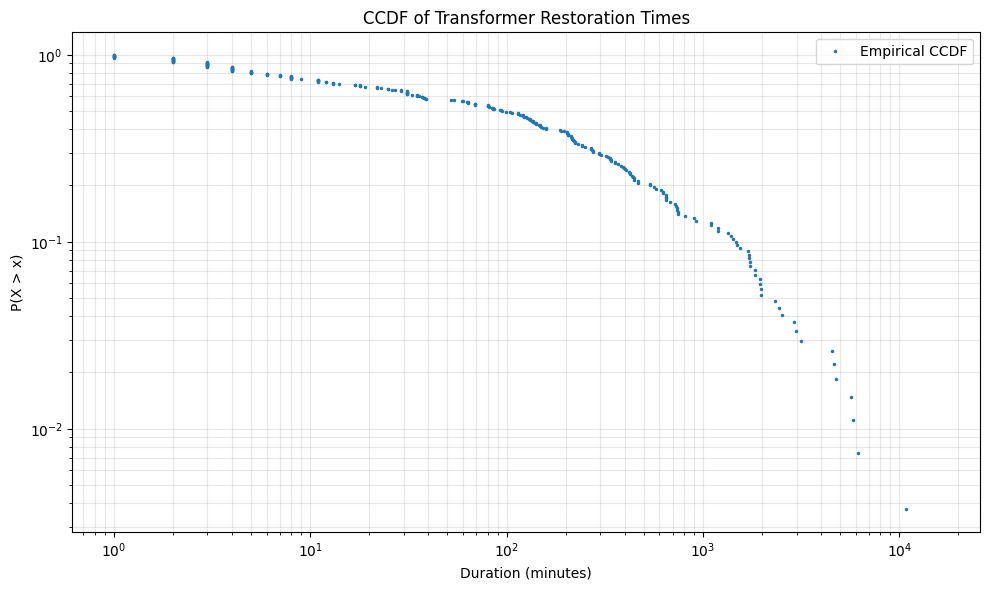

In [13]:
import matplotlib.pyplot as plt

# 依據修復時間做排序
duration_sorted = np.sort(df["Duration (minutes)"].values)

# 經驗互補累積分布 CCDF = 1 - 累積機率
ccdf = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)

plt.figure(figsize=(10, 6))
plt.loglog(duration_sorted, ccdf, marker=".", linestyle="none", markersize=3, label="Empirical CCDF")
plt.xlabel("Duration (minutes)")
plt.ylabel("P(X > x)")
plt.title("CCDF of Transformer Restoration Times")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. GMM 擬合

## 3.1 分層離散化

* 對全體 duration 以分位數切為 5 等分，作為後續 Stratified K-Fold 的分層依據，避免重尾分布所造成的 Fold 極端事件資料不平衡的狀況。
* 分位數分 5 層可避免「結果導向」的固定時間切點，並較能保護尾端的代表性。

In [14]:
# 對全體 duration 做分位數離散化 (分為 q 等分)，供 Stratified K-Fold 分層取樣
df["duration_bin"] = pd.qcut(
    df["Duration (minutes)"],
    q=5,
    labels=False,
    duplicates="drop"
)

# 確認分層分布
bin_count = df["duration_bin"].value_counts().sort_index()
bin_pct   = (bin_count / len(df) * 100).round(1)
display(pd.DataFrame({"Count": bin_count, "Pct (%)": bin_pct}))

,Count,Pct (%)
duration_bin,,
0,55,20.4
1,53,19.6
2,54,20.0
3,54,20.0
4,54,20.0


## 3.2 超參數 N 選擇

對 $n \in \{1,\dots,10\}$ 進行窮舉搜尋，以 BIC 最小者作為最佳 component 數。

重點觀察 $n=1$（對數常態）與最佳模型的 $\Delta\text{BIC}$：若 $\Delta\text{BIC}$ 很小，代表多族群並未帶來實質改善，對數常態已足夠；若顯著，則 GMM 確實捕捉到單族群對數常態無法描述的結構。

In [15]:
from sklearn.mixture import GaussianMixture

def fit_gmm(data, max_components=10):
    # 資料取對數並轉置
    log_data   = np.log(data).reshape(-1, 1)
    best_gmm   = None
    best_n     = None
    best_bic   = np.inf
    bic_scores = []
    gmm_by_n   = {}
    # 逐筆 n 做擬合
    for n in range(1, max_components + 1):
        gmm = GaussianMixture(
            n_components=n,
            random_state=42,
            max_iter=500,
            tol=1e-3,
            n_init=5
        )
        gmm.fit(log_data)

        if not gmm.converged_:
            print(f"n={n} 未收斂，跳過")
            bic_scores.append((n, np.nan))
            continue
        # 計算該 n 的 BIC 表現
        bic = gmm.bic(log_data)
        # 紀錄 BIC 
        bic_scores.append((n, round(bic, 2)))
        # 紀錄該 n 的 GMM 參數
        gmm_by_n[n] = gmm

        # 搜尋最佳 BIC 
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
            best_n   = n

    return best_gmm, best_n, bic_scores, gmm_by_n

# 取出修復時間資料
data = df["Duration (minutes)"].values
# 擬合
best_gmm, best_n, bic_scores, gmm_by_n = fit_gmm(data)

# BIC 紀錄表
bic_df = pd.DataFrame(bic_scores, columns=["n_components", "BIC"])
# 新增 BIC 差值欄位
bic_df["ΔBIC (vs best)"] = (bic_df["BIC"] - bic_df["BIC"].min()).round(2)

# Check
print(f"最佳 n_components (BIC 最小) : {best_n}")
n1_delta = bic_df.loc[bic_df["n_components"] == 1, "ΔBIC (vs best)"].values[0]
print(f"對數常態 (n=1) 相對最佳模型的 ΔBIC : {n1_delta}")
display(bic_df)

最佳 n_components (BIC 最小) : 7
對數常態 (n=1) 相對最佳模型的 ΔBIC : 51.61


,n_components,BIC,ΔBIC (vs best)
0,1,1230.08,51.61
1,2,1205.46,26.99
2,3,1220.70,42.23
3,4,1230.60,52.13
4,5,1246.96,68.49
5,6,1257.83,79.36
6,7,1178.47,0.00
7,8,1188.54,10.07
8,9,1194.42,15.95
9,10,1204.01,25.54


## 3.3 泛化能力評估：Stratified 5-Fold CV

以變異係數（Coefficient of Variation, CV）衡量模型在各 Fold 的 log-likelihood 變異情形，作為模型泛化能力的檢核。

* 結果 : CV 小於 5% 視為模型具備良好泛化能力

In [16]:
from sklearn.model_selection import StratifiedKFold
# K-Fold 分層取樣 
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
# 修復時間取對數
log_data    = np.log(df["Duration (minutes)"].values)
# 區間標籤
strat_label = df["duration_bin"].values

fold_scores = []
# 各 fold 擬合
for fold, (train_idx, test_idx) in enumerate(skf.split(log_data, strat_label)):
    X_train = log_data[train_idx].reshape(-1, 1)
    X_test  = log_data[test_idx].reshape(-1, 1)

    gmm = GaussianMixture(n_components=best_n, random_state=42, max_iter=500, n_init=5)
    # 擬合
    gmm.fit(X_train)
    # 擬合表現
    fold_scores.append(gmm.score(X_test))

# 計算 Fold CV
mean_ll = np.mean(fold_scores)
std_ll  = np.std(fold_scores)
cv_pct  = std_ll / abs(mean_ll) * 100

# Check
print(f"=== Stratified {K}-Fold CV (n_components={best_n}) ===")
for i, s in enumerate(fold_scores):
    print(f"  Fold {i+1}: {s:.4f}")
print(f"  Mean log-likelihood : {mean_ll:.4f} ± {std_ll:.4f}")
print(f"  CV                  : {cv_pct:.2f}%")

=== Stratified 5-Fold CV (n_components=7) ===
  Fold 1: -2.1573
  Fold 2: -2.0494
  Fold 3: -2.0253
  Fold 4: -2.1692
  Fold 5: -1.9628
  Mean log-likelihood : -2.0728 ± 0.0792
  CV                  : 3.82%


# 4. 比較 GMM 與 對數常態分佈

在對數空間下，比較對數常態（$n=1$）與最佳 GMM 的擬合品質。

同一張 log-log CCDF 疊上三條線：原始資料 / 對數常態（$n=1$）/ 最佳 GMM。

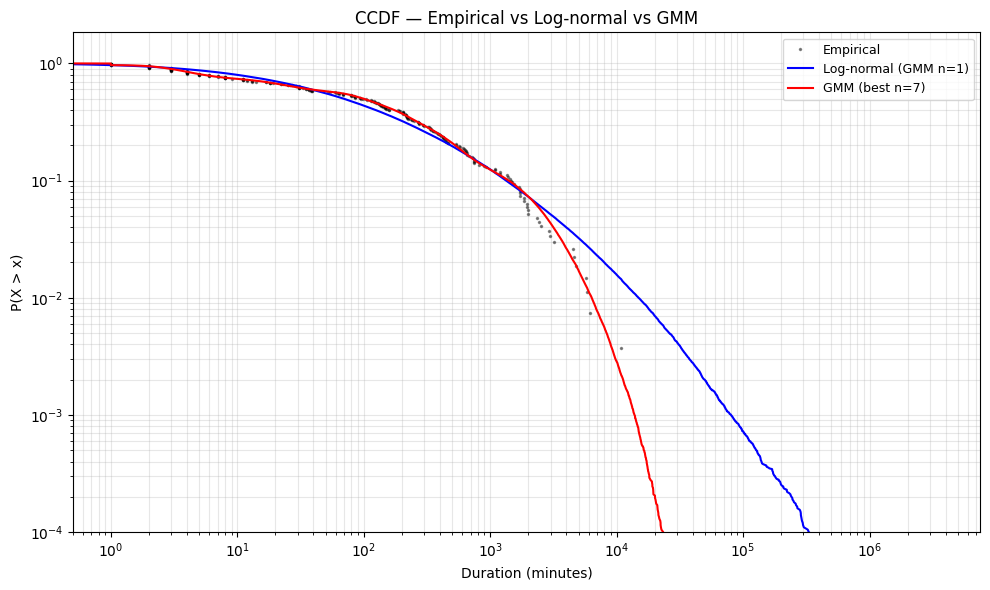

In [17]:
def gmm_sample_ccdf(gmm, n_samples=200_000):
    samples, _ = gmm.sample(n_samples)
    samples    = np.sort(np.exp(samples.flatten()))
    ccdf       = 1 - np.arange(1, len(samples) + 1) / len(samples)
    return samples, ccdf

data_sorted = np.sort(df["Duration (minutes)"].values)
ccdf_emp    = 1 - np.arange(1, len(data_sorted) + 1) / len(data_sorted)

s1, c1 = gmm_sample_ccdf(gmm_by_n[1])
sb, cb = gmm_sample_ccdf(best_gmm)

plt.figure(figsize=(10, 6))
plt.loglog(data_sorted, ccdf_emp, "k.", markersize=3, alpha=0.4, label="Empirical")
plt.loglog(s1, c1, "b-", linewidth=1.5, label="Log-normal (GMM n=1)")
plt.loglog(sb, cb, "r-", linewidth=1.5, label=f"GMM (best n={best_n})")
plt.xlim(left=0.5)
plt.ylim(bottom=1e-4)
plt.xlabel("Duration (minutes)")
plt.ylabel("P(X > x)")
plt.title("CCDF — Empirical vs Log-normal vs GMM")
plt.legend(fontsize=9)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 5. 相對誤差

**原理**：對每個資料點 $x_i$，計算實際 CCDF 與模型理論 CCDF 之間的相對誤差：

$$\text{rel-err}_i = \frac{\left| \text{CCDF}_{\text{emp}}(x_i) - \text{CCDF}_{\text{model}}(x_i) \right|}{\text{CCDF}_{\text{emp}}(x_i)}$$

模型 CCDF 以**解析式**計算（對數空間下各族群常態 CDF 的加權和）

## 5.1 一般統計

In [18]:
from scipy.stats import norm as sp_norm

def gmm_ccdf_at(x_vals, gmm):
    """
    計算 log-space GMM 在指定 x 值 (分鐘)的解析 CCDF (超越機率)。
    """
    # 排序防呆：確保輸入為遞增順序
    x_vals  = np.sort(np.asarray(x_vals, dtype=float))
    # 資料取對數
    log_x   = np.log(x_vals)
    # 建立符合資料長度的 0 陣列
    cdf     = np.zeros(len(log_x))
    # 計算 該 x 值的累積發生機率
    for k in range(gmm.n_components):
        mu_k    = gmm.means_[k, 0]
        sigma_k = np.sqrt(gmm.covariances_[k, 0, 0])
        cdf    += gmm.weights_[k] * sp_norm.cdf((log_x - mu_k) / sigma_k)
    return 1.0 - cdf

# 資料排序
data_sorted = np.sort(df["Duration (minutes)"].values)
# 資料總數量
n           = len(data_sorted)
# 實際機率
ccdf_emp    = 1 - np.arange(1, n + 1) / n

def rel_err_stats(gmm, label):
    # 計算實際點位修復時間在 GMM 的估計發生機率
    ccdf_model = gmm_ccdf_at(data_sorted, gmm)
    mask       = ccdf_emp > 0
    rel_err    = np.abs(ccdf_emp[mask] - ccdf_model[mask]) / ccdf_emp[mask]
    print(f"=== {label} ===")
    print(f"  中位數相對誤差 : {np.median(rel_err)*100:.2f}%")
    print(f"  平均相對誤差   : {np.mean(rel_err)*100:.2f}%")
    print(f"  最大相對誤差   : {rel_err.max()*100:.2f}%")
    print()
    return rel_err

print("── 逐點 CCDF 相對誤差 ──\n")
rel_err_lognorm = rel_err_stats(gmm_by_n[1], "Log-normal (GMM n=1)")
rel_err_best    = rel_err_stats(best_gmm, f"GMM (best n={best_n})")

── 逐點 CCDF 相對誤差 ──

=== Log-normal (GMM n=1) ===
  中位數相對誤差 : 8.04%
  平均相對誤差   : 11.75%
  最大相對誤差   : 290.27%

=== GMM (best n=7) ===
  中位數相對誤差 : 1.39%
  平均相對誤差   : 3.44%
  最大相對誤差   : 44.46%



## 5.2 離散化相對誤差分級表

**誤差判斷標準**

| 誤差範圍 | 評估 |
|---------|------|
| < 5% | 非常好 |
| 5 ~ 10% | 良好 |
| 10 ~ 20% | 尚可 |
| > 20% | 偏差 |

兩模型並列，比較各誤差級距的點數與累積比例。

In [19]:
# 定義表現區間
bins_err   = [(0, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, float("inf"))]
# 表現區間標籤
labels_err = ["< 5%（非常好）", "5 ~ 10%（良好）", "10 ~ 20%（尚可）", "> 20%（偏差）"]

def err_table(rel_err, label):
    rows       = []
    cumulative = 0.0
    for (lo, hi), lab in zip(bins_err, labels_err):
        # 統計相對誤差資料 > 區間下線；< 區間上限
        cnt = int(((rel_err >= lo) & (rel_err < hi)).sum())
        # 計算百分比
        pct = cnt / len(rel_err) * 100
        # 累積百分比
        cumulative += pct
        
        # 建立區間表現資料內容
        rows.append({"誤差區間": lab, "點數": cnt,
                     "比例 (%)": round(pct, 1), "累積比例 (%)": round(cumulative, 1)})
    tbl = pd.DataFrame(rows).set_index("誤差區間")
    print(f"=== {label} ===")
    display(tbl)

err_table(rel_err_lognorm, "Log-normal (GMM n=1)")
err_table(rel_err_best, f"GMM (best n={best_n})")

=== Log-normal (GMM n=1) ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,87,32.3,32.3
5 ~ 10%（良好）,89,33.1,65.4
10 ~ 20%（尚可）,77,28.6,94.1
> 20%（偏差）,16,5.9,100.0


=== GMM (best n=7) ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,239,88.8,88.8
5 ~ 10%（良好）,13,4.8,93.7
10 ~ 20%（尚可）,6,2.2,95.9
> 20%（偏差）,11,4.1,100.0


# 6. 存檔

In [20]:
import json
params_path = os.path.join(DATA_DIR, "repair_params.json")
all_params  = json.load(open(params_path)) if os.path.exists(params_path) else {}

all_params["transformer"] = {
    "n_components": int(best_gmm.n_components),
    "weights":      best_gmm.weights_.tolist(),
    "means":        best_gmm.means_.flatten().tolist(),
    "stds":         np.sqrt(best_gmm.covariances_.flatten()).tolist(),
}

with open(params_path, "w") as f:
    json.dump(all_params, f, indent=2, ensure_ascii=False)
print(json.dumps(all_params["transformer"], indent=2, ensure_ascii=False))


{
  "n_components": 7,
  "weights": [
    0.2217134086286343,
    0.13070218888042356,
    0.18549470110488137,
    0.151707552543815,
    0.13407000108171233,
    0.14299129647019534,
    0.03332085129033812
  ],
  "means": [
    1.334853657670598,
    6.199817933875412,
    3.1568673110871175,
    7.568902668955231,
    4.639029476226731,
    5.399165973162142,
    0.0
  ],
  "stds": [
    0.4991706545134378,
    0.36160822345457594,
    0.6008020420015963,
    0.7825169917583183,
    0.3310803515846307,
    0.32891208026967605,
    0.001
  ]
}
